No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

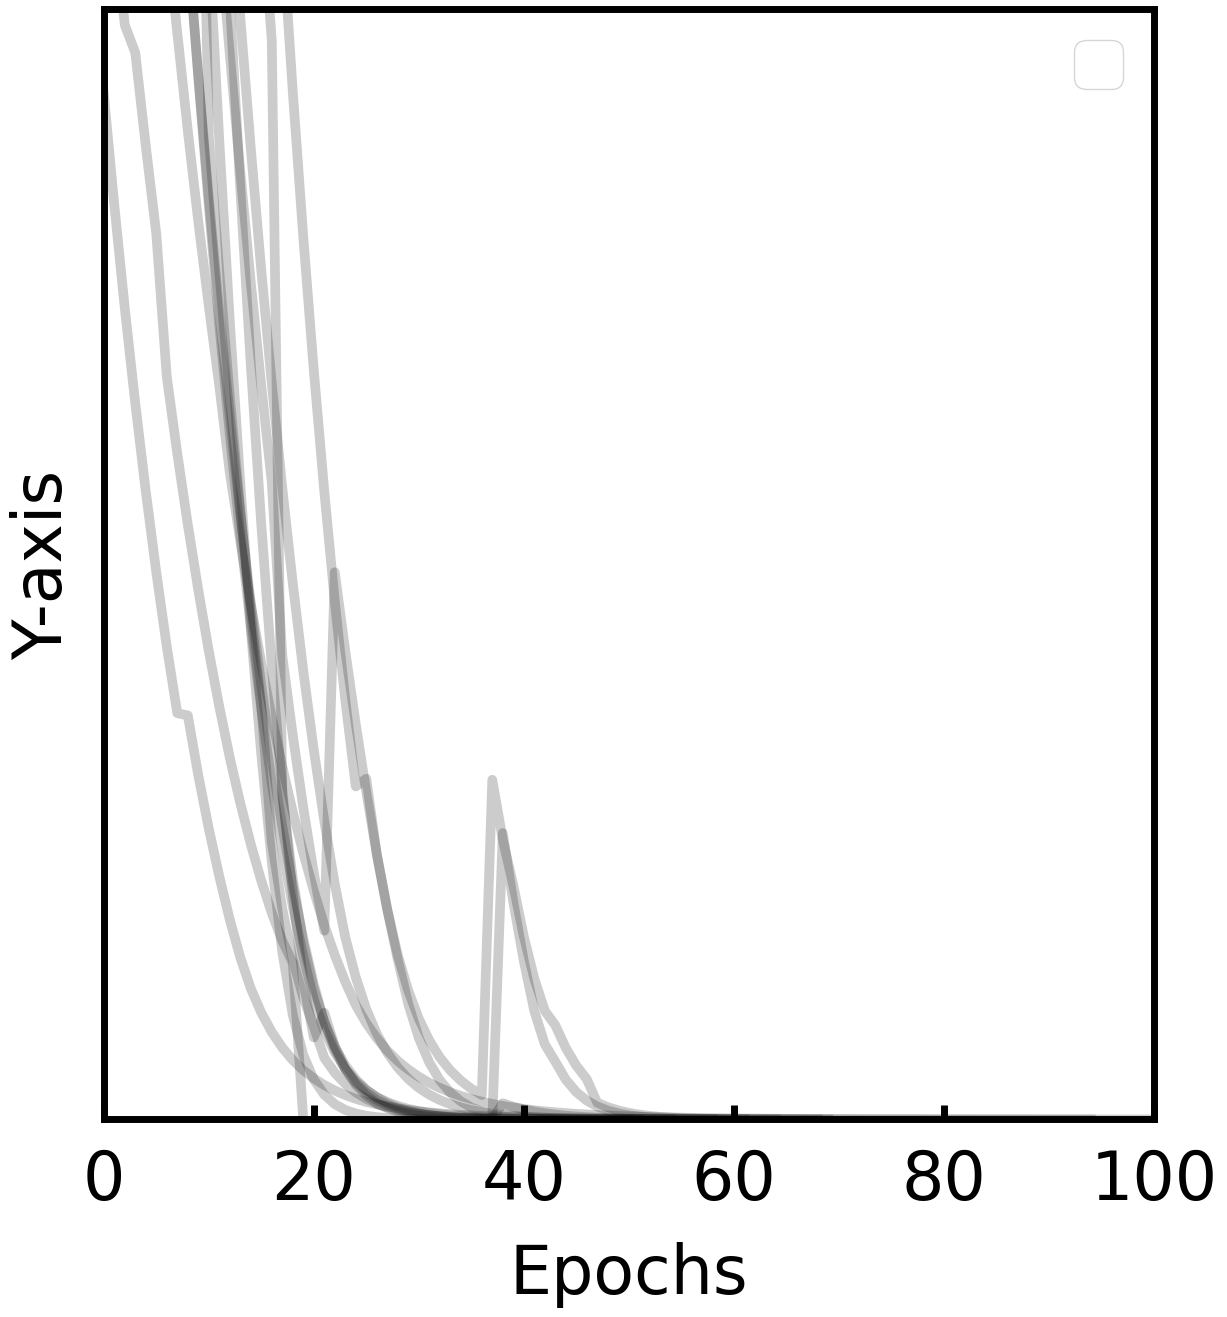

In [2]:
from toolbox import manuscriptPlots
import numpy as np
import pandas as pd
import os
# colormap = {"":"red", "final":"blue"}
# labelmap = {"init": "Initial", "final": "Final"}
# filename = "graphs/stress_tensor_manuscript/kappa_{:.2f}.png".format(p)

plotter = manuscriptPlots.plot()
plotter.set_ylim(0,1e-2)
plotter.set_xlim(0,100)
# plotter.set_title(" p = {:.2f}".format(p))
plotter.set_xlabel("Epochs")
plotter.set_xticks([20*i for i in range(100)])
plotter.set_yticks([10*i for i in range(1,10)])
plotter.set_yScaled()
plotter.initialize_figure()

for i in range(20):
    input_file = "sp_1_cell_increase/run_{}/costs.txt".format(i)
    if not os.path.isfile(input_file):
        continue
    costs = np.loadtxt(input_file)
    if costs[-1]>1e-6:
        continue
    # print(costs)
    plotter.plot_xy([i for i in range(len(costs))],costs, color= "black", label = "_None",alpha = 0.2)
    # plotter.histogram_from_dataframe(df["Final_s0"],color="green", label = r"$\sigma_{trained}>\sigma_{initial}$", bins=20,alpha = 0.6)
    # plotter.ax.plot((5,5),(0,10), color = "black", alpha = 0.2, linestyle = "--", label = "Initial")
    # plotter.ax.legend()
    plotter.save_fig("/Users/shabeebameen/Projects/tvm-fire/sp_1_cell_costs.jpg")

In [7]:
import os
experiments_list = ["sp_1_cell_increase",
                    "sp_1_cell_decrease",
                    # "sp_2_cell_increase",
                    # "sp_2_cell_decrease",
                    "sp_5_cell_increase",
                    "sp_5_cell_decrease"]
for experiment in experiments_list:
    os.makedirs(experiment, exist_ok=True)
    # os.system("scp mameen@smatter-login.syr.edu:/home/mameen/{}/histogram_data.csv {}".format(experiment,experiment))
    os.system("scp mameen@smatter-login.syr.edu:/home/mameen/{}/costs.csv {}/".format(experiment,experiment))

    # for i in range(20):
    #     dir = experiment+"/"+"run_{}/".format(i)
    #     os.makedirs(dir, exist_ok= True)
    #     os.system("scp mameen@smatter-login.syr.edu:/home/mameen/{}/costs.csv {}/".format(experiment,experiment))


In [5]:
0.21744816883482376*1.75

0.3805342954609416

In [6]:
(.381-0.21744816883482376)/.217

0.7536950744938997

In [ ]:
import pandas as pd
import numpy as np
import glob


dir = "two_cell_training/"
initial_stress = pd.read_csv("{}initial_stress.csv".format(dir))
means = []
final_stress_file = glob.glob("{}*.stresses.csv".format(dir))[-1]
for final_stress_file in sorted(glob.glob("{}*.stresses.csv".format(dir))):
    final_stress = pd.read_csv(final_stress_file)
    targets = final_stress["Target"].to_numpy()
    means.append(np.mean(abs((final_stress["Current"].to_numpy() - targets))/final_stress["Target"].to_numpy()))
   

   cellID    Stress
0     110  0.213505
1      91  0.310052
   CellID  Target   Current
0     110   0.235  0.234242
1      91   0.341  0.340898
0.001761960228373355
[-0.09146754 -0.09075644]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


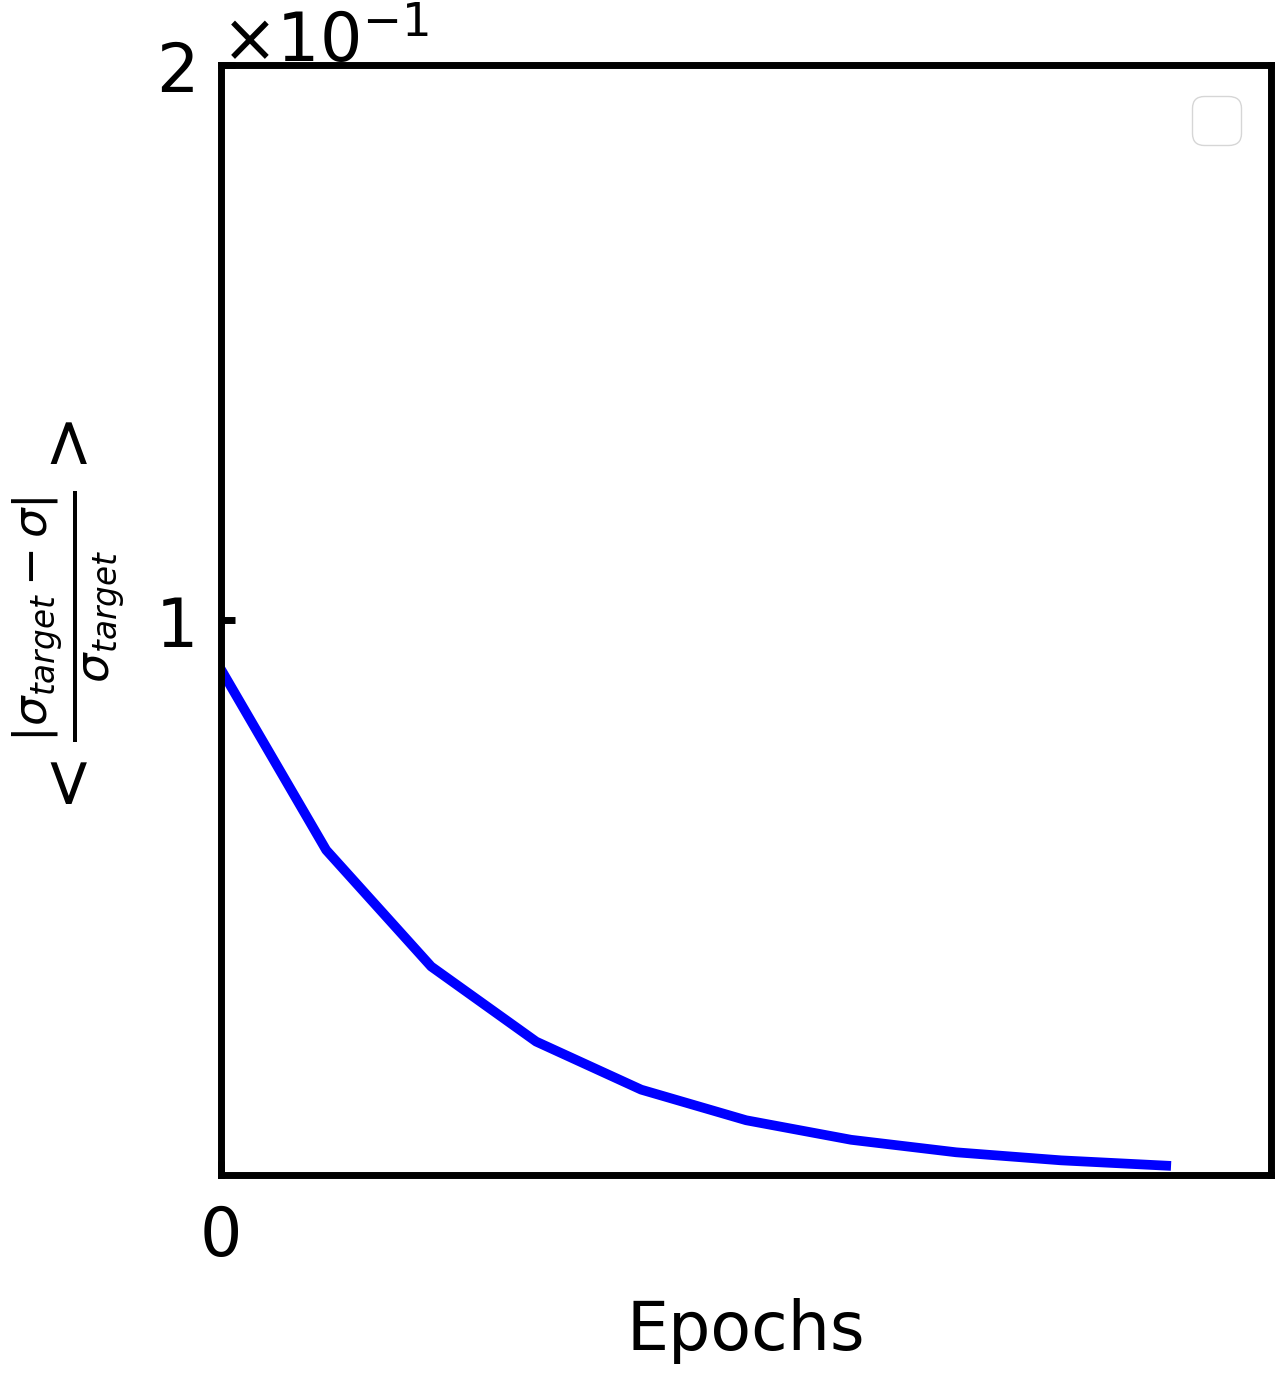

In [28]:
from toolbox import manuscriptPlots
import glob
def training_plot(dir):
    plotter = manuscriptPlots.plot()
    plotter.set_ylim(0,0.2)
    plotter.set_xlim(0,np.ceil(len(np.loadtxt("{}costs.txt".format(dir)))/10)*10)
    plotter.set_xticks([50*i for i in range(1000)])
    plotter.set_yticks([.1*i for i in range(1,100)])
    plotter.set_xlabel("Epochs")
    plotter.set_ylabel(r"$<\frac{|\sigma_{target}-\sigma|}{\sigma_{target}}>$")
    plotter.set_yScaled()
    plotter.initialize_figure()

    initial_stress = pd.read_csv("{}initial_stress.csv".format(dir))
    targets = pd.read_csv("{}0000.stresses.csv".format(dir))["Target"].to_numpy()

    means = [np.mean(abs((initial_stress["Stress"].to_numpy() - targets))/targets)]

    final_stress_file = glob.glob("{}*.stresses.csv".format(dir))[-1]
    for final_stress_file in sorted(glob.glob("{}*.stresses.csv".format(dir))):
        final_stress = pd.read_csv(final_stress_file)
        targets = final_stress["Target"].to_numpy()
        means.append(np.mean(abs((final_stress["Current"].to_numpy() - targets))/targets))
        iters = np.arange(len(means))
    plotter.plot_xy(iters, means, color = "blue", label = "_final")
    plotter.save_fig("training.jpg".format(dir))

training_plot("two_cell_training/")

In [ ]:
import os
dir = "samples/"
run = "7_0"
os.system("mkdir -p {}".format(dir+run))
os.system("cp init/7_0/conf {}".format(dir+run))
os.system("cd {} && python /Users/shabeebameen/Projects/tvm-fire/scripts/tvm/main.py conf".format(dir+run))

/Users/shabeebameen/.asdf/installs/python/3.10.14/bin/python: can't open file '/Users/shabeebameen/Projects/tvm-fire/samples/7_0/Users/shabeebameen/Projects/tvm-fire/scripts/tvm/main.py': [Errno 2] No such file or directory


512

In [42]:
from toolbox.periodic import PeriodicTissue
from toolbox.patterns import Patterns
import os
dir = "init/10_0/"
file = "minimized.txt"
# cpp_executable_dir = "tvm/build/"
ids = []
tissue = PeriodicTissue.from_config(dir,file)
for cellID,cell in tissue.cells_.items():
    if cell.center_ is None:
        continue
    if cell.crossBoundary_:
        continue
    if cell.center_[2]>3.7 and cell.center_[2]<4.5:
        ids.append(cellID)
tissue.write_cell_collection_vtk(cells_array=ids, filename="layer.vtk")

In [15]:
import glob
import pandas as pd
import numpy as np
dir = sorted(glob.glob("patternA/*.bulk.txt"))[-1]

# remove the part before the last slash in dir
file = dir.split("/")[-1]
print(dir)
dir = "patternA/"
df = pd.read_csv("{}initial_stress.csv".format(dir))
print(df)
cellID_to_stress = {int(i): float(stress) for i, stress in zip(df["cellID"].to_numpy(), df["Stress"].to_numpy())}
print(cellID_to_stress)
print(np.loadtxt("{}costs.txt".format(dir)))

patternA/0014.bulk.txt
   cellID    Stress
0     142  0.277201
{142: 0.2772011738735123}
[1.57e-04 9.56e-05 6.59e-05 4.53e-05 3.12e-05 2.16e-05 1.49e-05 1.04e-05
 7.20e-06 5.00e-06 3.48e-06 2.43e-06 1.68e-06 1.17e-06 8.21e-07]


In [ ]:
## create cross section of a periodic tissue
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox.minimization import FIREminimization
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np
import pandas as pd
import glob

dir = "7_bidisperse_5_4.9_0.5_increase/"
# dir = "7_mono_0.5_decrease/"
df = pd.read_csv("{}stresses.csv".format(dir))
print(df["CellID"])
training_cell = df["CellID"].to_numpy()[0]
ids = [int(os.path.basename(f).split(".")[0]) for f in glob.glob("{}*.bulk.txt".format(dir))]
final_iter = max(ids)
file = "{}.bulk.txt".format(final_iter)
sample = PeriodicTissue.from_config(dir,file)
min = FIREminimization.periodic_tissue(sample)
min.load_cell_parameters("cellParameters.{}.input".format(final_iter))

for cellID, cell in sample.cells_.items():
    cell.vtk_scalar_ = cell.s0_
    cell.vtk_scalar_ = stress.calculate_max_shear_stress(sample, cellID)
normal = np.array([1,0,0])
center = sample.cells_[training_cell].center_
print(sample.cells_[training_cell].s0_)
makeSampleCrossSection(sample=min._config, center = center, normal = normal, filename = "cross_section.vtk")
single_cell = sample.extract_cell(training_cell)
makeSampleCrossSection(sample=single_cell, center=center, normal = normal, filename="single_cell_cross_section.vtk")



0    331
Name: CellID, dtype: int64
5.0


In [10]:
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox.minimization import FIREminimization
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np
import pandas as pd
import glob
dir = "mp_2_cells/run_0/PatternB/"
df = pd.read_csv("{}initial_stress.csv".format(dir))
# print(df["cellID"])
# ids = [int(os.path.basename(f).split(".")[0]) for f in glob.glob("{}*.bulk.txt".format(dir))]
# ids = sorted(ids)
# final_iter = 33
# for iter in range(final_iter+1):
file = "0000.bulk.txt"
sample = PeriodicTissue.from_config(dir,file)
sample.write_cell_collection_vtk(df["cellID"].to_numpy(),"target_cells_isolated.vtk",use_scalar=False)
# sample.write_cell_collection_vtk([64],"target_cells_isolated.vtk",use_scalar=False)


# min = FIREminimization.periodic_tissue(sample)

# min.load_cell_parameters("cellParameters.{}.input".format(iter))
# for i, row in df.iterrows():
#     cellID = row["CellID"]
#     target_stress = row["Target"]
#     cell = sample.cells_[cellID]
#     # shear = stress.calculate_max_shear_stress(sample, cellID)
#     # cell.max_shear_stress_ = shear
#     # vtk_scalar = abs(cell.max_shear_stress_ - target_stress)/ target_stress
#     for polygonID in cell.polygons_:
#         polygon = sample.polygons_[polygonID]
#         # polygon.vtk_scalar_ = vtk_scalar
# for cellID in df["CellID"].to_numpy():
    # sample.write_cell_collection_vtk(df["CellID"].to_numpy(),"{}.target_cells.vtk".format(iter),use_scalar=True)
    # sample.write_cell_collection_vtk([cellID],"{}single.{}.vtk".format(dir,cellID),use_scalar=False)

